In [11]:
#initializing workspace
import pandas as pd
import matplotlib.pyplot as plt
import trxtools as tt
import os
from pyCRAC.Parsers import GTF2
import pyBigWig
import numpy as np
from trxtools.BigWig import *
from scipy.signal import argrelextrema

pathGTF = "../references/hg41.ncbiRefSeq.rRNA.gtf"
gtf = GTF2.Parse_GTF()
gtf.read_GTF(pathGTF)

# # loading chromosome sequences
# pathTAB = "../seq_references/Saccharomyces_cerevisiae.EF4.74.dna.toplevel.shortChrNames.tab"
# gtf.read_TAB(pathTAB)
# sequences = pd.read_csv(pathTAB, sep='\t',names=['chr','sequence'],index_col=0)
# chr_len = sequences['sequence'].str.len()

# print(gtf.strand("RNA45SN1"), gtf.chromosome("RNA45SN1"), gtf.chromosomeCoordinates("RNA45SN1"))
# print(gtf.strand("RNA45SN2"), gtf.chromosome("RNA45SN2"), gtf.chromosomeCoordinates("RNA45SN2"))
# print(gtf.strand("RNA45SN3"), gtf.chromosome("RNA45SN3"), gtf.chromosomeCoordinates("RNA45SN3"))

print("45S rRNA lengths:")
RNA45SN1 = gtf.chromosomeCoordinates("RNA45SN1")[1] - gtf.chromosomeCoordinates("RNA45SN1")[0]
RNA45SN2 = gtf.chromosomeCoordinates("RNA45SN2")[1] - gtf.chromosomeCoordinates("RNA45SN2")[0]
RNA45SN3 = gtf.chromosomeCoordinates("RNA45SN3")[1] - gtf.chromosomeCoordinates("RNA45SN3")[0]
print(RNA45SN1, RNA45SN2, RNA45SN3)

print("5' ETS lengths:")
RNA18SN1 = gtf.chromosomeCoordinates("RNA18SN1")[0] - gtf.chromosomeCoordinates("RNA45SN1")[0]
RNA18SN2 = gtf.chromosomeCoordinates("RNA18SN2")[0] - gtf.chromosomeCoordinates("RNA45SN2")[0]
RNA18SN3 = gtf.chromosomeCoordinates("RNA18SN3")[0] - gtf.chromosomeCoordinates("RNA45SN3")[0]
print(RNA18SN1, RNA18SN2, RNA18SN3)

print("45S without 5' ETS lengths:")
print(RNA45SN1 - RNA18SN1, RNA45SN2 - RNA18SN2, RNA45SN3 - RNA18SN3)

print("18S rRNA lengths are the same (1869 bp)")
# print(gtf.chromosomeCoordinates("RNA18SN1")[1] - gtf.chromosomeCoordinates("RNA18SN1")[0])
# print(gtf.chromosomeCoordinates("RNA18SN2")[1] - gtf.chromosomeCoordinates("RNA18SN2")[0])
# print(gtf.chromosomeCoordinates("RNA18SN3")[1] - gtf.chromosomeCoordinates("RNA18SN3")[0])

l01_45S = ["RNA45SN1", "RNA45SN2", "RNA45SN3"]
l02_5ETS = ["RNA18SN1", "RNA18SN2", "RNA18SN3"]
l03_18S = ["RNA18SN1", "RNA18SN2", "RNA18SN3"]
l04_25S = ["RNA25SN1", "RNA25SN2", "RNA25SN3"]
l05_5S = ["RNA5S"+str(i) for i in range(1, 17+1)]  # RNA5S1 to RNA5S17

# l06_5Spseudogenes = ["RNA5SP"+str(i) for i in range(18, 536+1)]  # RNA5SP18 to RNA5SP536 - some pseudogenes are missing

45S rRNA lengths:
13351 13315 13309
5' ETS lengths:
3654 3643 3631
45S without 5' ETS lengths:
9697 9672 9678
18S rRNA lengths are the same (1869 bp)


In [2]:
# Processing sites for 45S pre-rRNA
df00_RNAcoordinates = pd.DataFrame()
for i in ['N1', 'N2', 'N3']:
    start = gtf.chromosomeCoordinates(f'RNA45S{i}')[0]
    start18 = gtf.chromosomeCoordinates(f'RNA18S{i}')[0]
    end18 = gtf.chromosomeCoordinates(f'RNA18S{i}')[1]
    start58 = gtf.chromosomeCoordinates(f'RNA5-8S{i}')[0]
    end58 = gtf.chromosomeCoordinates(f'RNA5-8S{i}')[1]
    start28 = gtf.chromosomeCoordinates(f'RNA28S{i}')[0]
    end28 = gtf.chromosomeCoordinates(f'RNA28S{i}')[1]
    end = gtf.chromosomeCoordinates(f'RNA45S{i}')[1]
    df00_RNAcoordinates[f'RNA45S{i}'] = [start,
                                        start18,
                                        end18,
                                        start58,
                                        end58,
                                        start28,
                                        end28,
                                         end]
    
df00_RNAcoordinates.index = ['start_RNA45', 'start_RNA18', 'end_RNA18', 'start_RNA5-8', 'end_RNA5-8', 'start_RNA28', 'end_RNA28', 'end_RNA45']
df00_RNAcoordinates = df00_RNAcoordinates.T
df00_RNAcoordinates = df00_RNAcoordinates.subtract(df00_RNAcoordinates['start_RNA45'], axis=0)
df00_RNAcoordinates

,start_RNA45,start_RNA18,end_RNA18,start_RNA5-8,end_RNA5-8,start_RNA28,end_RNA28,end_RNA45
RNA45SN1,0,3654,5523,6600,6757,7924,12990,13351
RNA45SN2,0,3643,5512,6583,6740,7900,12954,13315
RNA45SN3,0,3631,5500,6571,6728,7891,12946,13309


In [7]:
flank = 100
bwDir_04 = "../04_BigWig/"

#loading datasets
data_files_read_04 = [f for f in os.listdir(bwDir_04) if 'read' in f and "bw" in f]

print(len(os.listdir(bwDir_04)))
print(len(data_files_read_04))

bwDir_14 = "../14_BigWig/"

#loading datasets
data_files_read_14 = [f for f in os.listdir(bwDir_14) if 'read' in f and "bw" in f]

print(len(os.listdir(bwDir_14)))
print(len(data_files_read_14))

40
32
32
32


# Cyclon profile along RNA45S N1

Error retrieving sequence for RNA45SN1: No sequence information available for RNA45SN1. Did you load the reference sequence using the read_TAB method?

Error retrieving sequence for RNA45SN1: No sequence information available for RNA45SN1. Did you load the reference sequence using the read_TAB method?

Experiments: 
['AG241010_Cyclon_none_120mJ_2_read', 'AG241010_Cyclon_none_120mJ_1_read']
Experiments: 
['AG241010_Cyclon_none_120mJ_2_read', 'AG241010_Cyclon_none_120mJ_1_read']


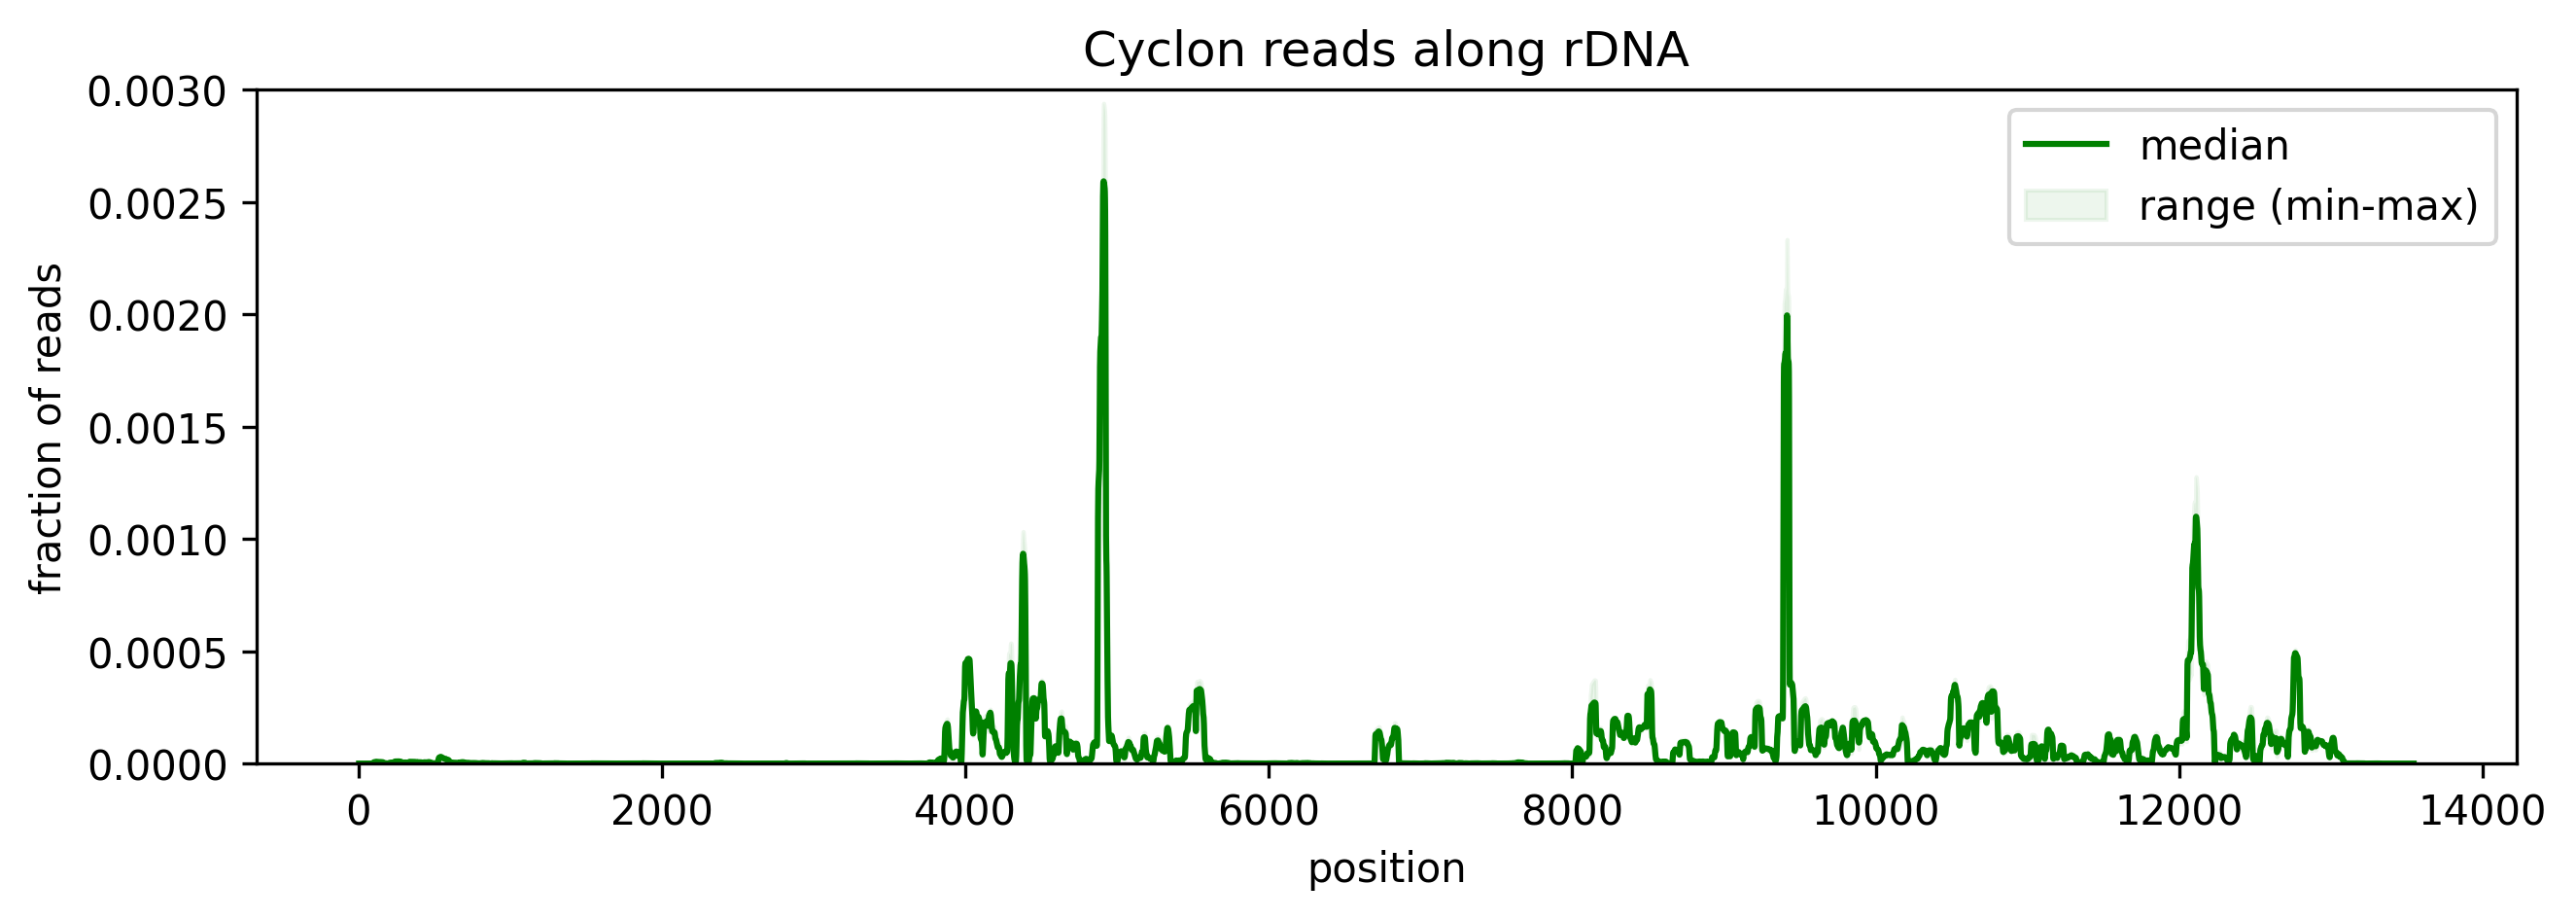

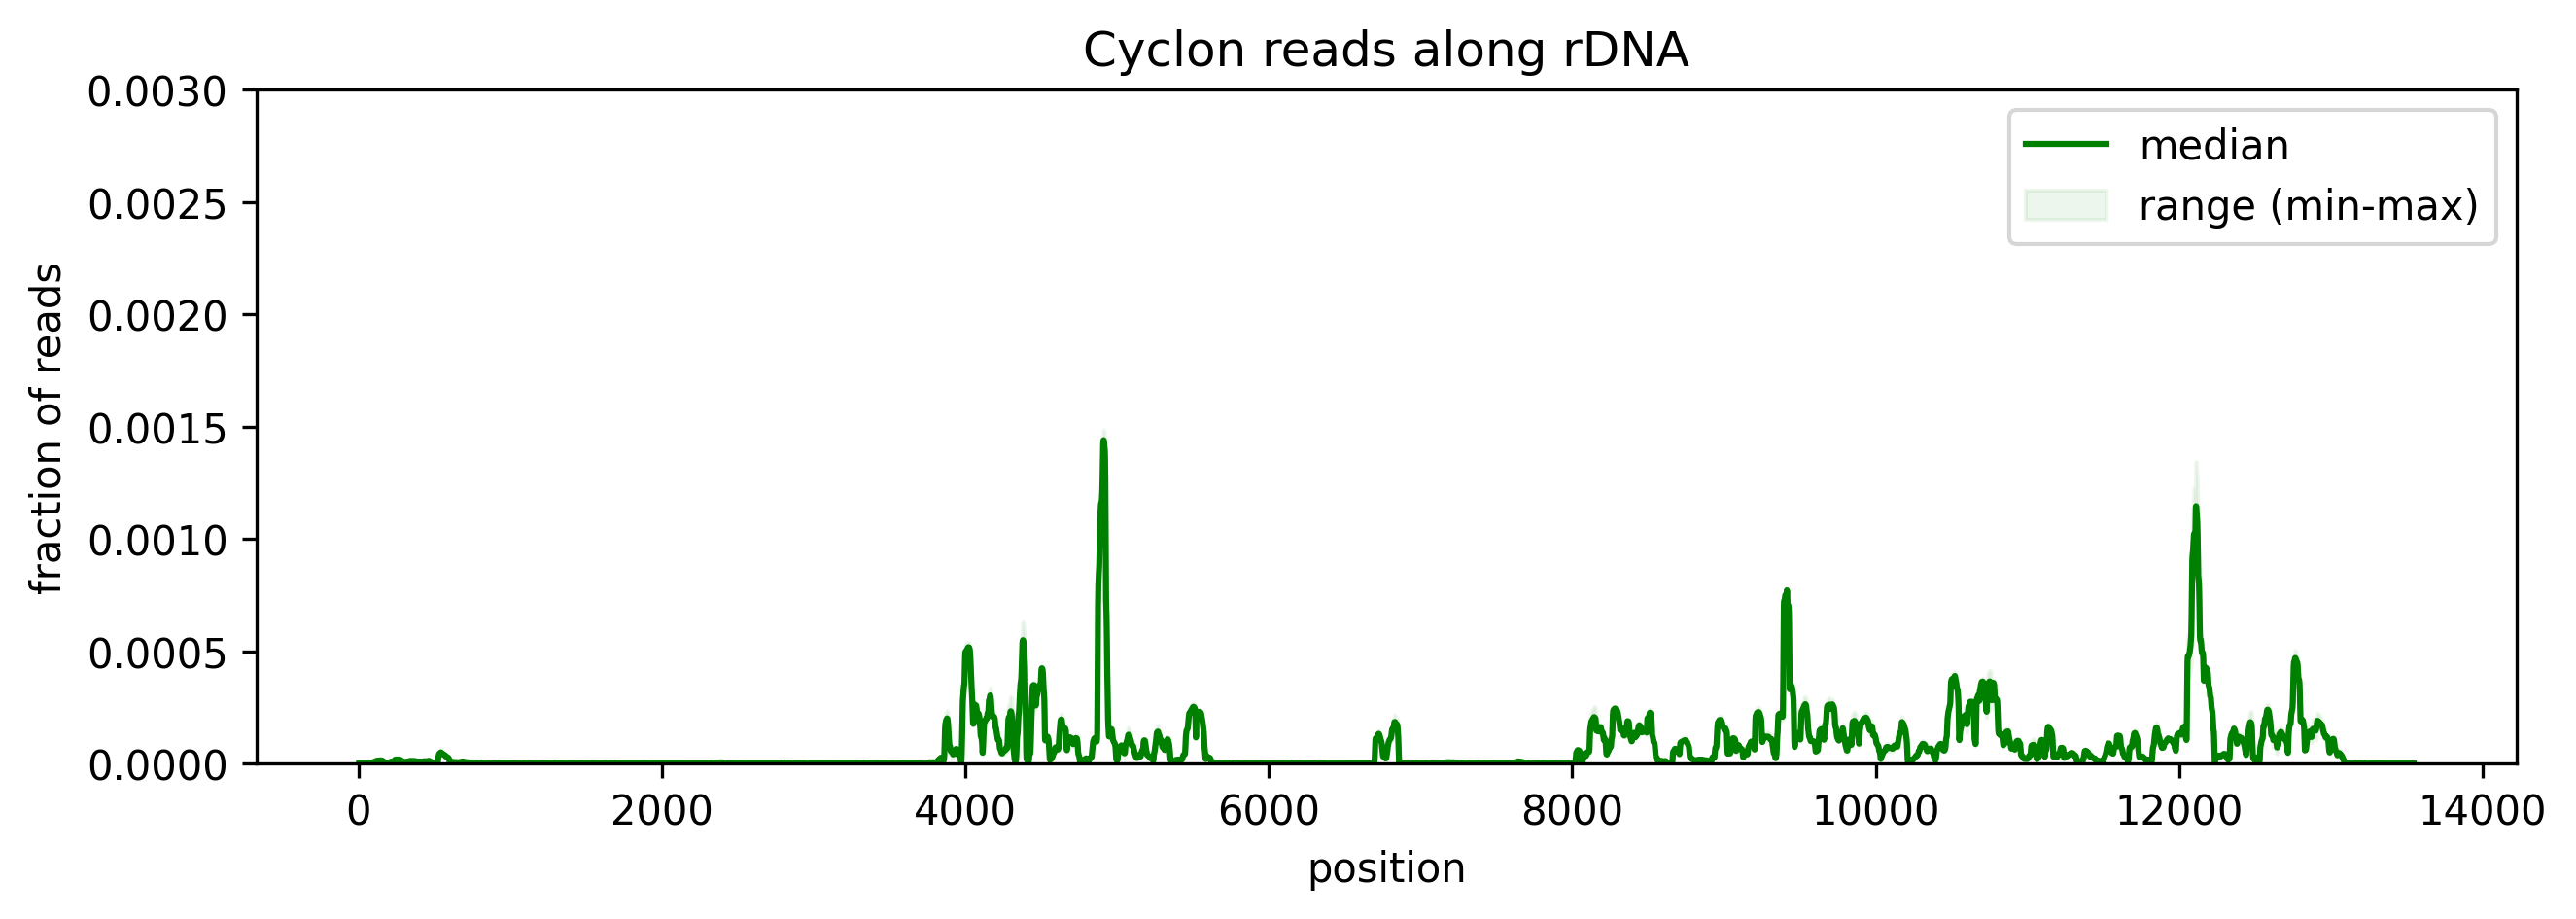

In [ ]:
df01_RNA45S_read_04 = geneFromBigWig(gene_name="RNA45SN1", data_path=bwDir_04, data_files=data_files_read_04, gtf=gtf,ranges=flank)
df02_RNA45S_read_14 = geneFromBigWig(gene_name="RNA45SN1", data_path=bwDir_14, data_files=data_files_read_14, gtf=gtf,ranges=flank)

df11_RNA45SN1 = tt.profiles.preprocess(df01_RNA45S_read_04,
                                     let_in=['Cyclon'], 
                                     let_out=["CPM", "Cyclon-"],stats=True)
df21_RNA45SN1 = tt.profiles.preprocess(df02_RNA45S_read_14,
                                     let_in=['Cyclon'], 
                                     let_out=["CPM", "Cyclon-"],stats=True)

tt.plotting.plot_as_box_plot(df11_RNA45SN1, figsize=(10,3), title="Cyclon reads along rDNA",
                            #  start=300,stop=7300,
                             dpi=300,ylim=(None,0.003),offset=0,fname='Fig_01_RNA45SN1.png')
tt.plotting.plot_as_box_plot(df21_RNA45SN1, figsize=(10,3), title="Cyclon reads along rDNA",
                            #  start=300,stop=7300,
                             dpi=300,ylim=(None,0.003),offset=0,fname='Fig_02_RNA45SN1_14.png')

Error retrieving sequence for RNA45SN1: No sequence information available for RNA45SN1. Did you load the reference sequence using the read_TAB method?

Experiments: 
['AG241010_Cyclon_none_120mJ_2_raw', 'AG241010_Cyclon_none_120mJ_1_raw']
Error retrieving sequence for RNA45SN2: No sequence information available for RNA45SN2. Did you load the reference sequence using the read_TAB method?

Experiments: 
['AG241010_Cyclon_none_120mJ_2_raw', 'AG241010_Cyclon_none_120mJ_1_raw']
Error retrieving sequence for RNA45SN3: No sequence information available for RNA45SN3. Did you load the reference sequence using the read_TAB method?

Experiments: 
['AG241010_Cyclon_none_120mJ_2_raw', 'AG241010_Cyclon_none_120mJ_1_raw']


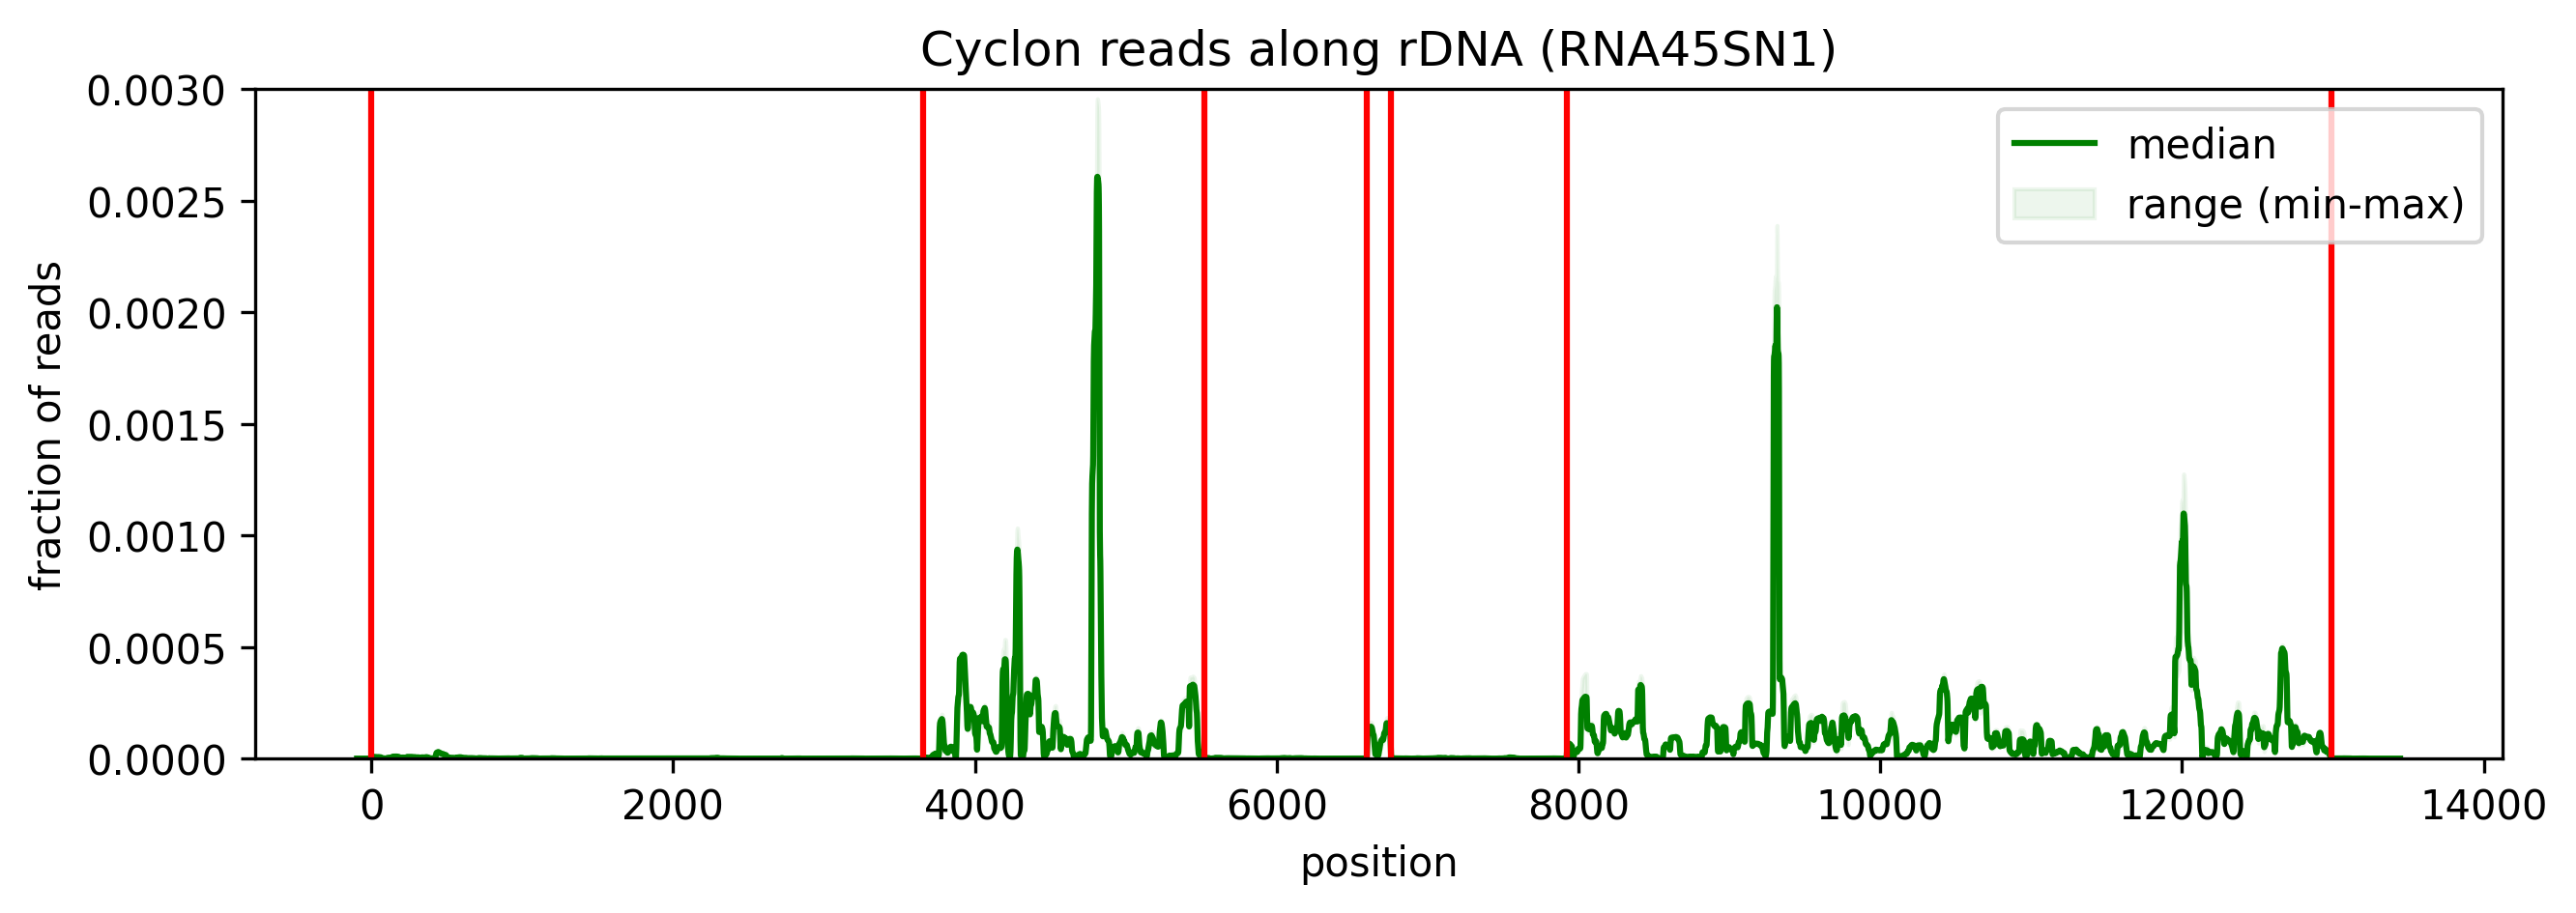

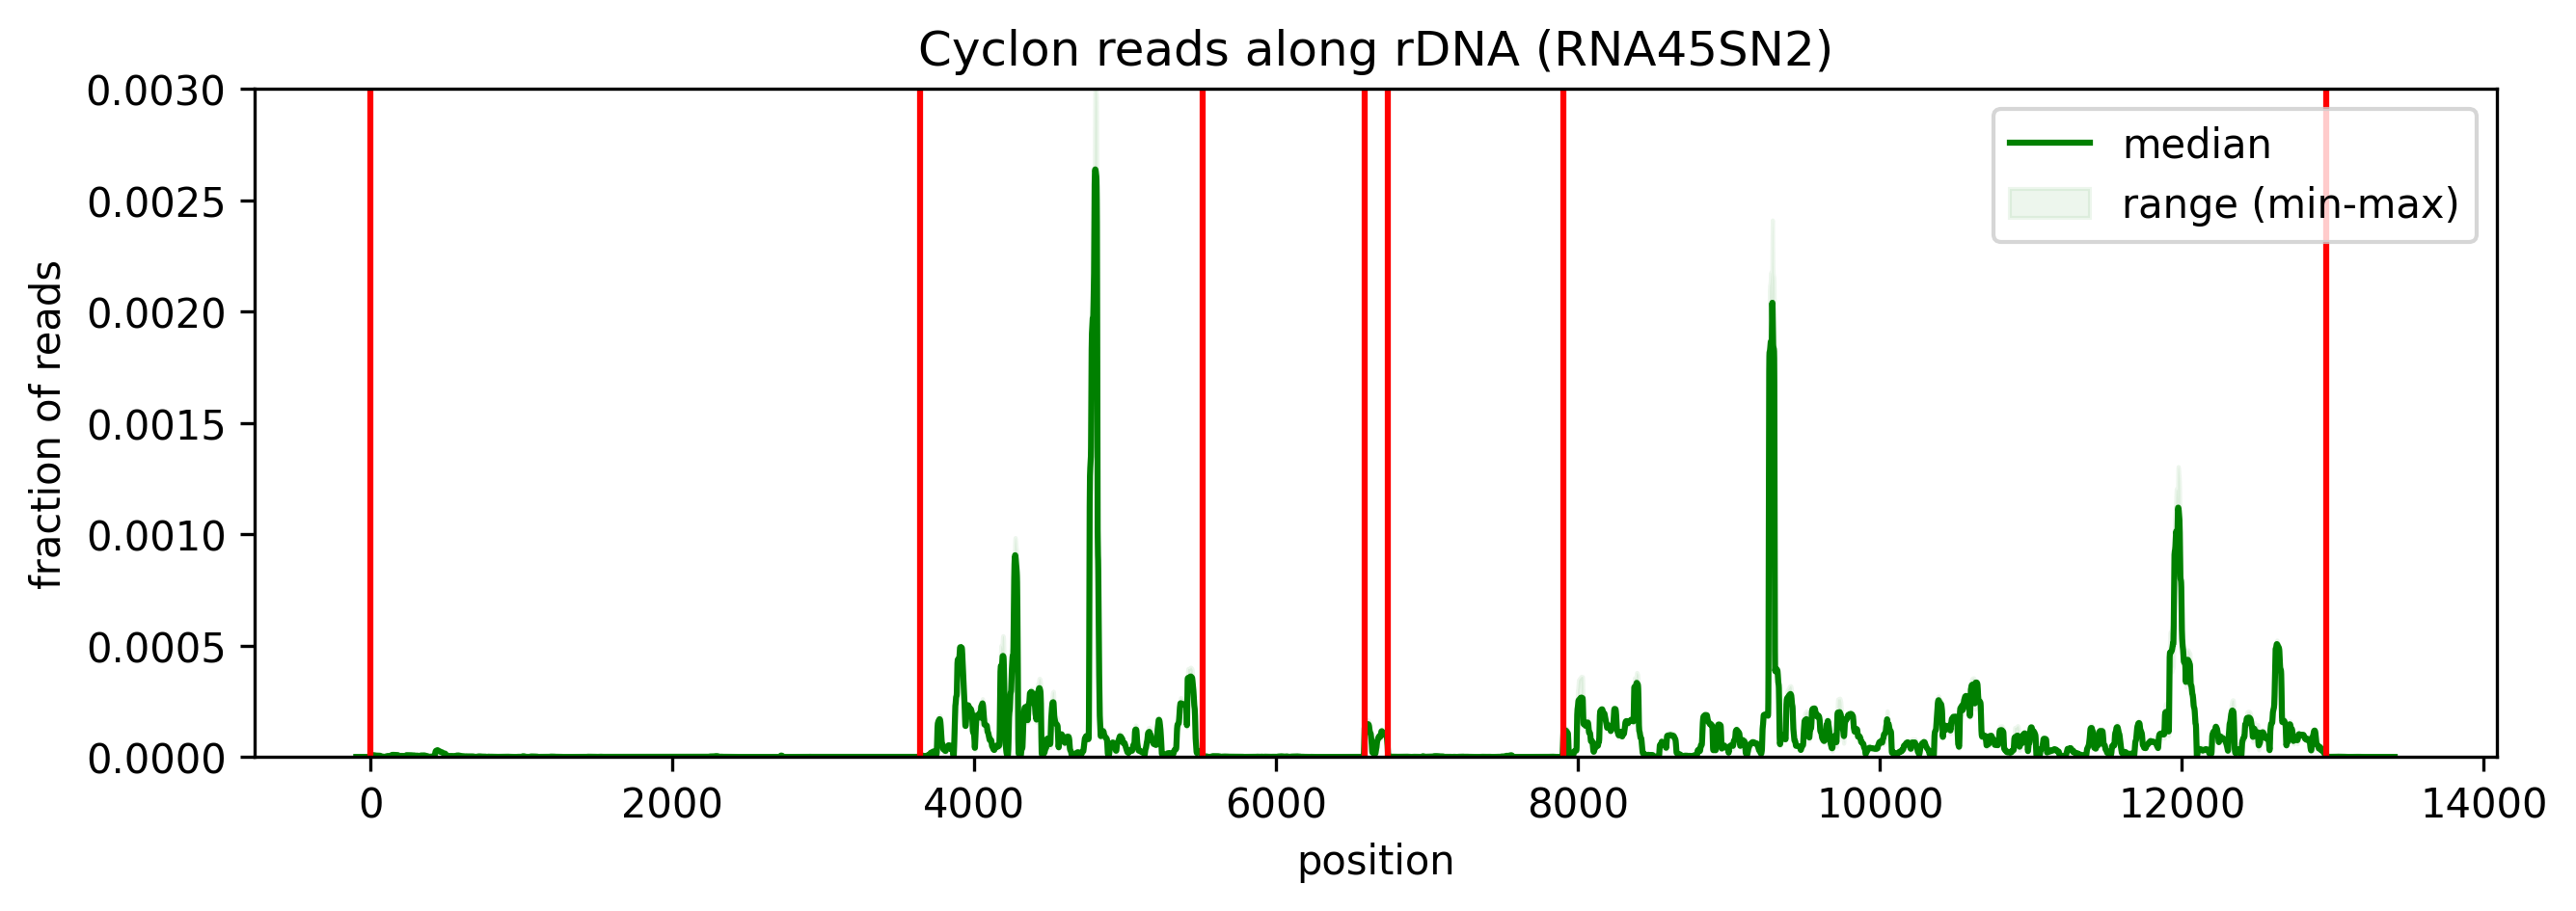

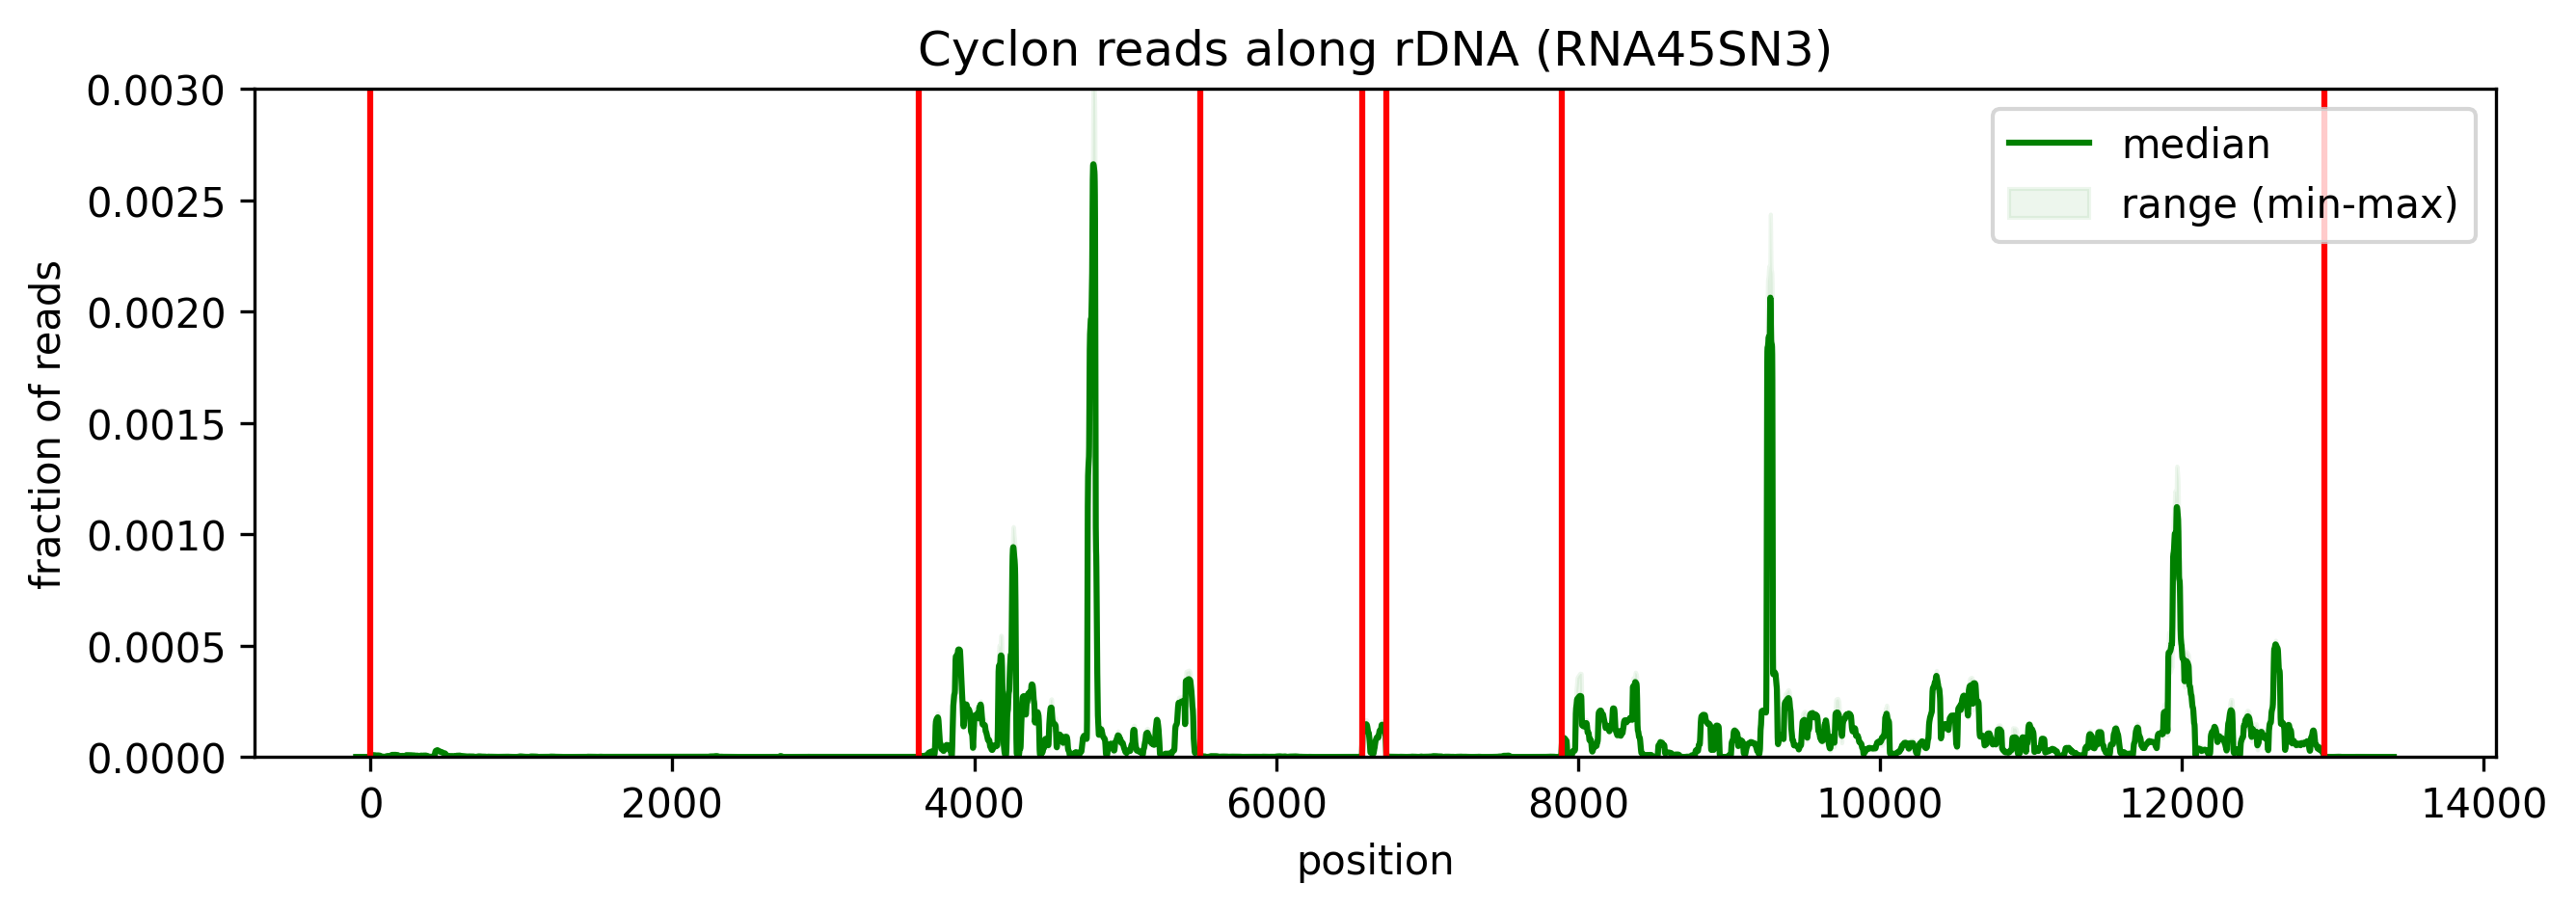

In [27]:
for i in ['N1', 'N2', 'N3']:
    df_temp_datasets = geneFromBigWig(gene_name=f"RNA45S{i}", data_path=pathDir, data_files=data_files_raw, gtf=gtf,ranges=flank)
    df_temp_profile = tt.profiles.preprocess(df_temp_datasets,
                                     let_in=['Cyclon'], let_out=[],stats=True)
    processing_sites = df00_RNAcoordinates.loc[f'RNA45S{i}'].to_list()
    tt.plotting.plot_as_box_plot(df_temp_profile, figsize=(10,3), title=f"Cyclon reads along rDNA (RNA45S{i})",
                                 h_lines=processing_sites,
                             dpi=300,ylim=(None,0.003),offset=100,fname=f'Fig_02_RNA45S{i}.png')

Error retrieving sequence for RNA45SN1: No sequence information available for RNA45SN1. Did you load the reference sequence using the read_TAB method?

Experiments: 
['AG241010_Cyclon_none_120mJ_2_raw', 'AG241010_Cyclon_none_120mJ_1_raw']
Error retrieving sequence for RNA45SN2: No sequence information available for RNA45SN2. Did you load the reference sequence using the read_TAB method?

Experiments: 
['AG241010_Cyclon_none_120mJ_2_raw', 'AG241010_Cyclon_none_120mJ_1_raw']
Error retrieving sequence for RNA45SN3: No sequence information available for RNA45SN3. Did you load the reference sequence using the read_TAB method?

Experiments: 
['AG241010_Cyclon_none_120mJ_2_raw', 'AG241010_Cyclon_none_120mJ_1_raw']


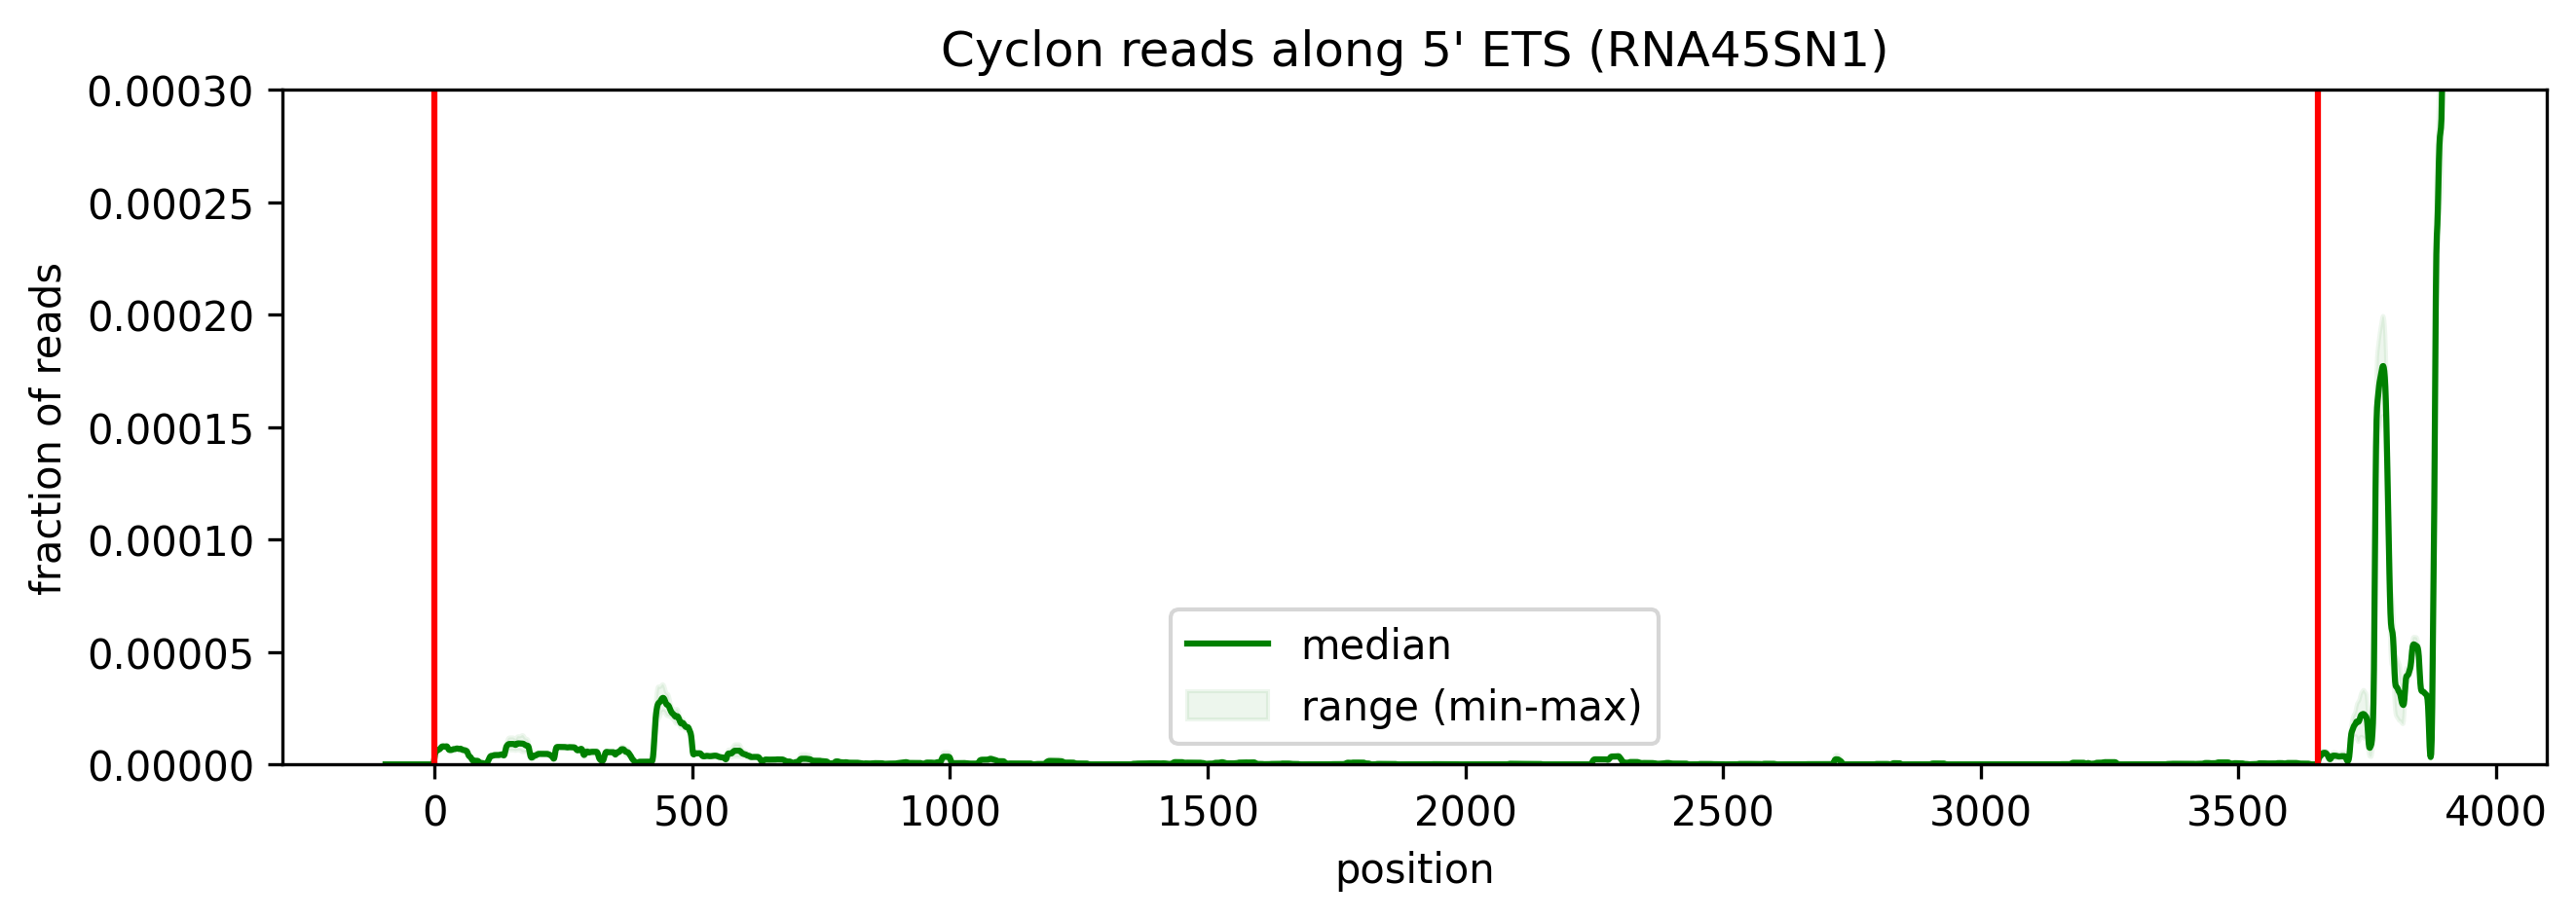

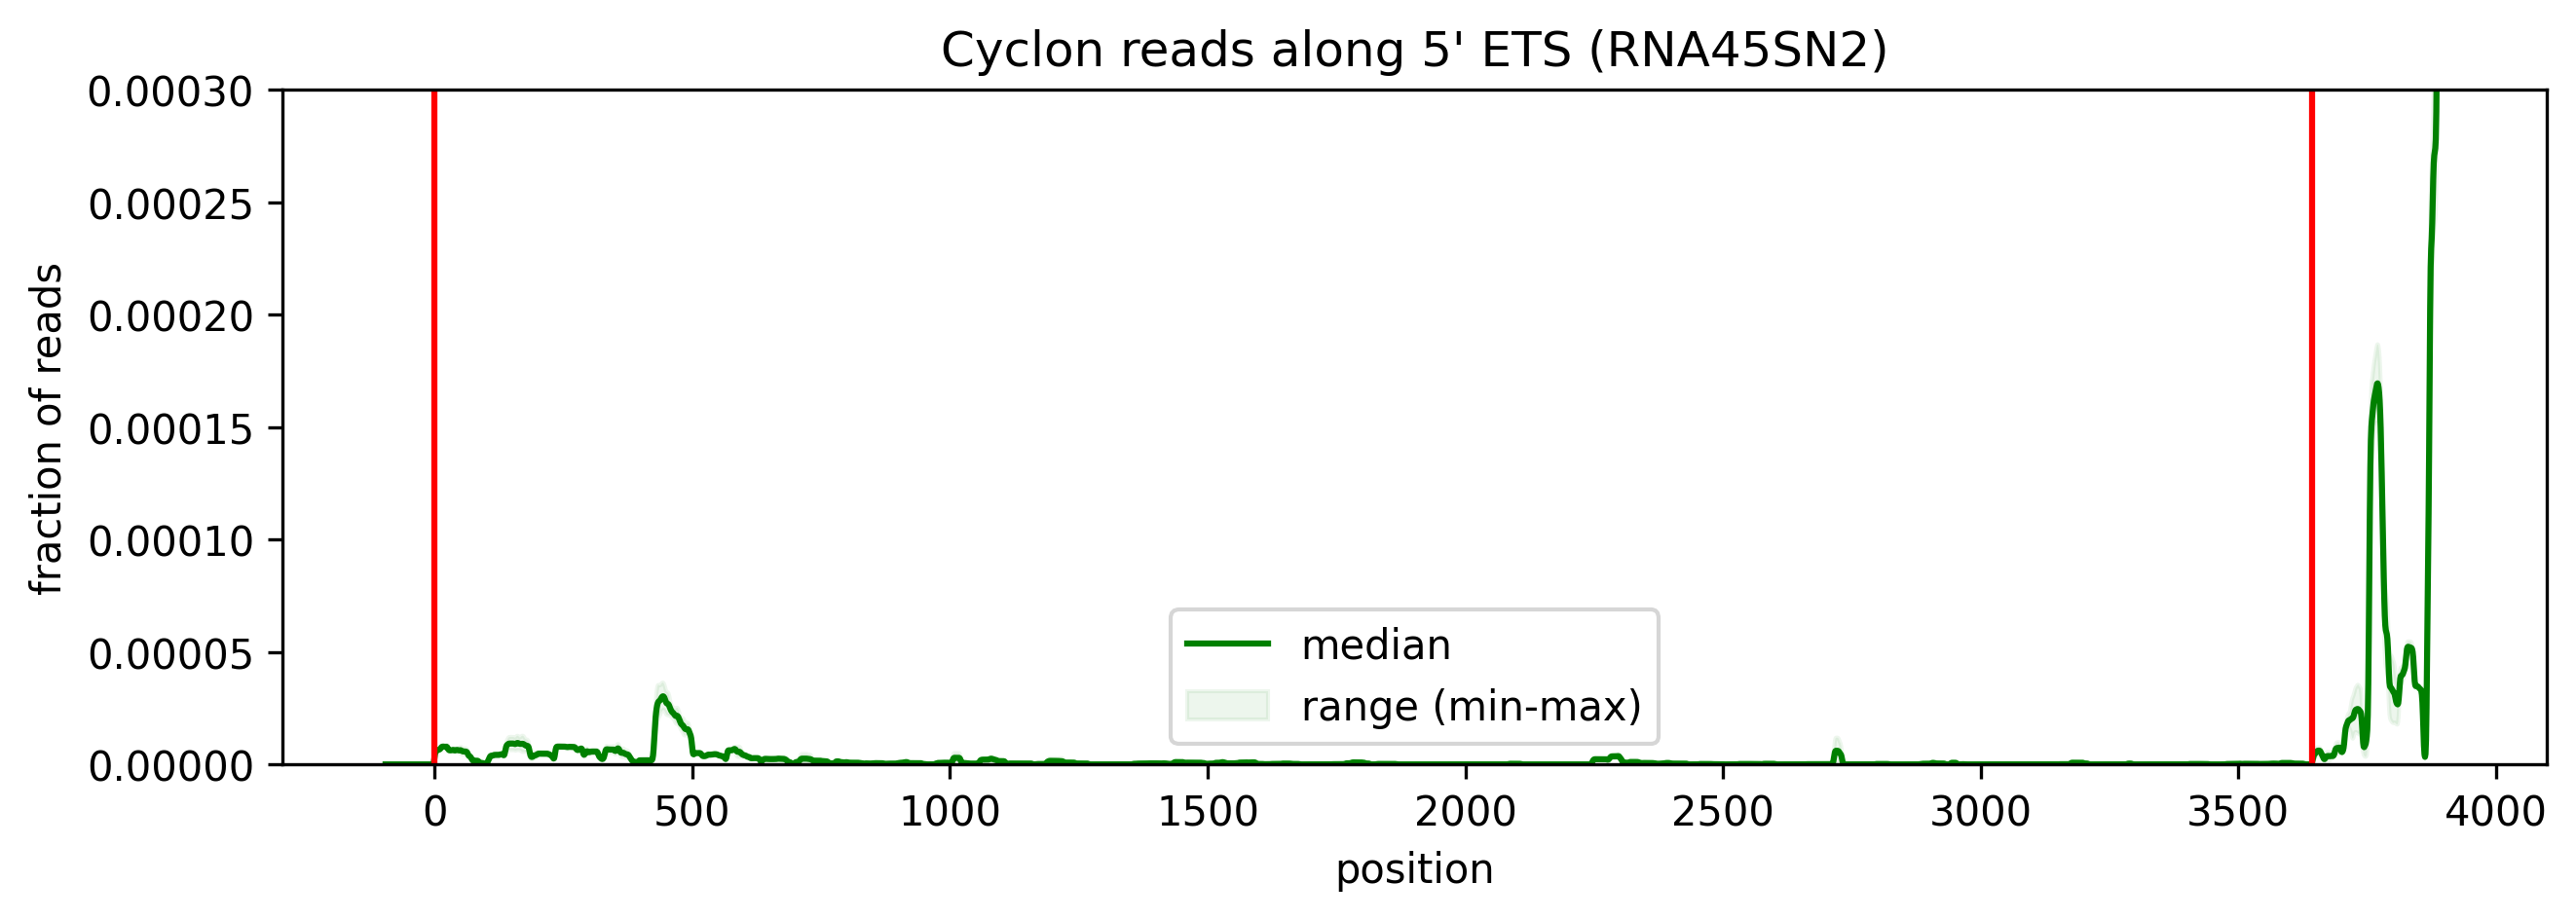

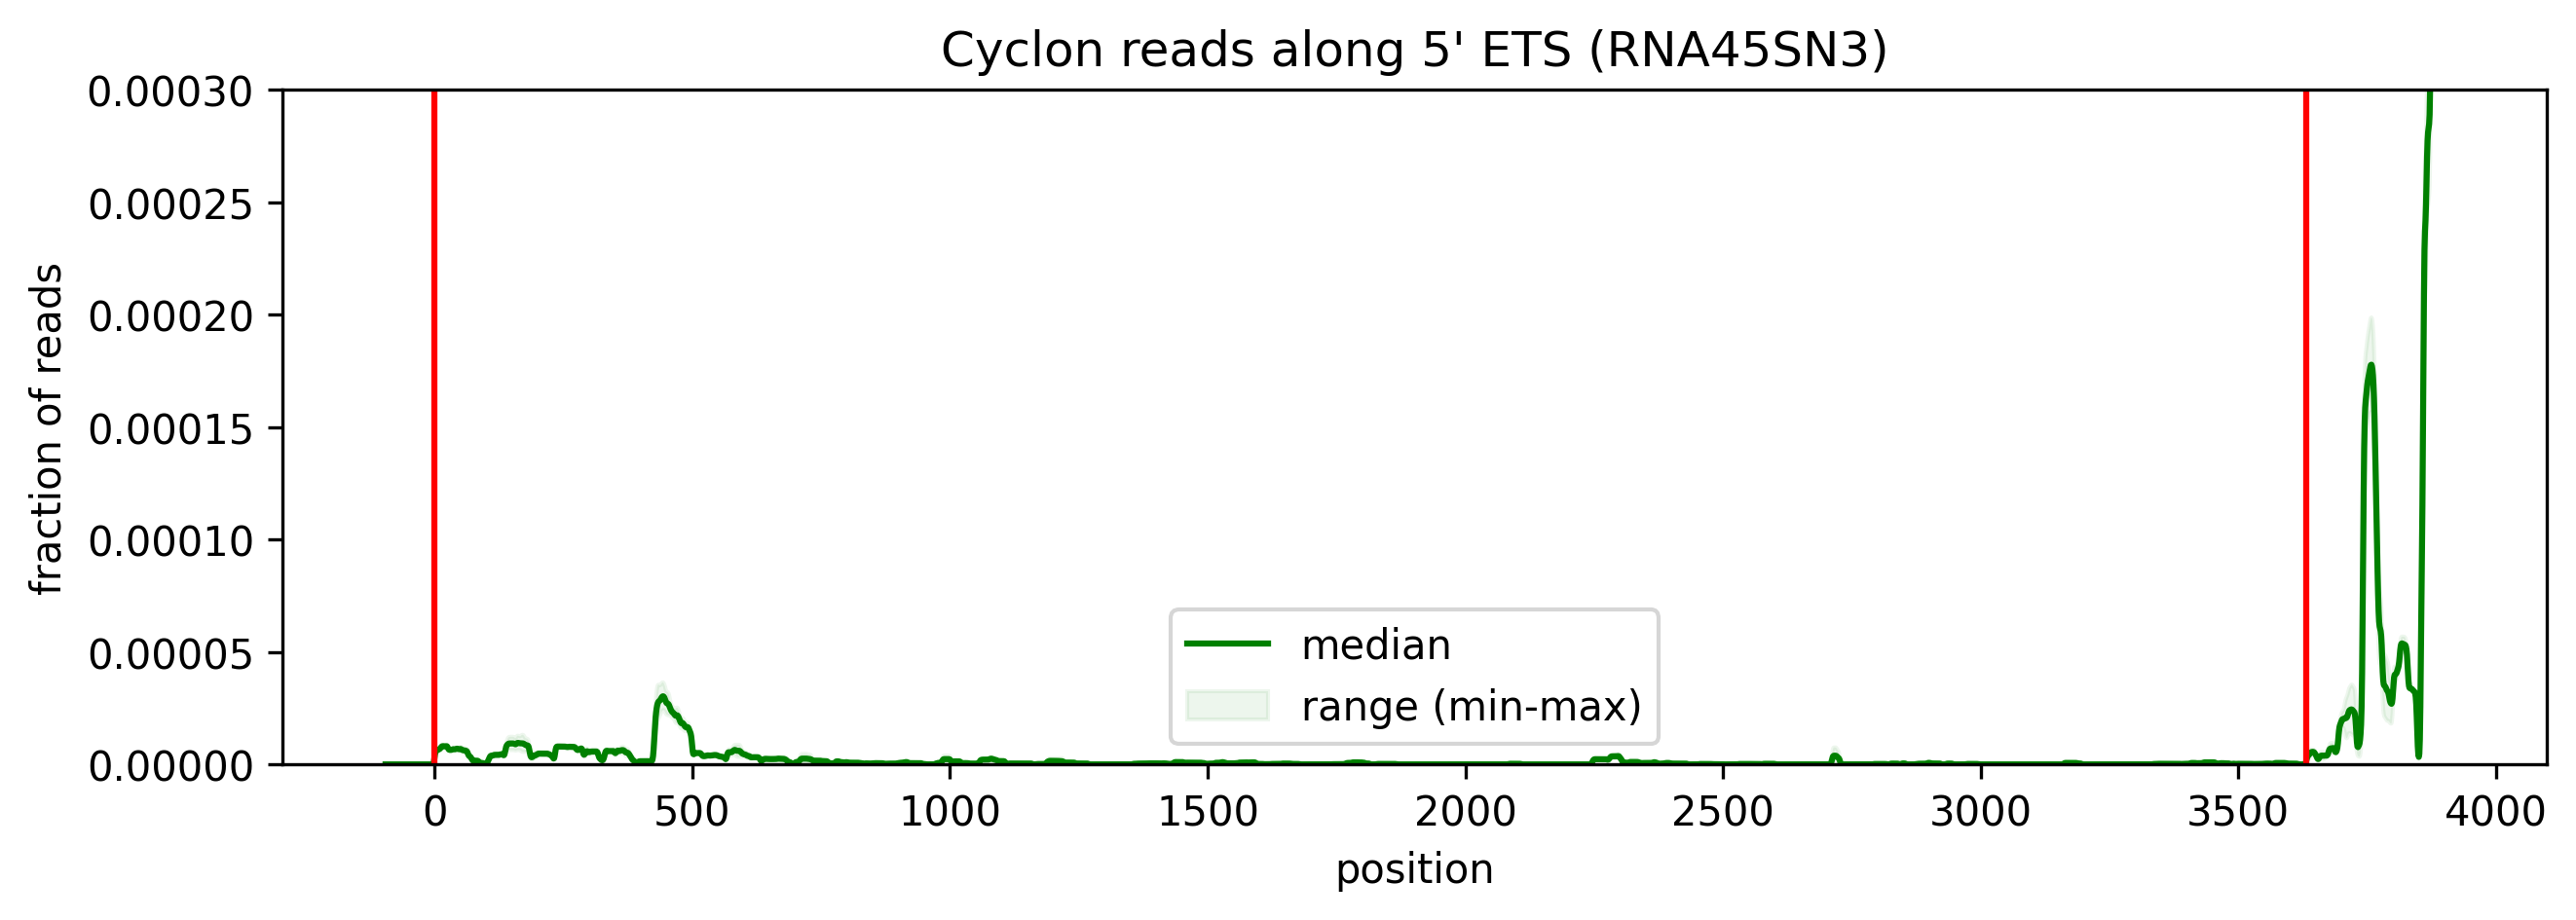

In [28]:
for i in ['N1', 'N2', 'N3']:
    df_temp_datasets = geneFromBigWig(gene_name=f"RNA45S{i}", data_path=pathDir, data_files=data_files_raw, gtf=gtf,ranges=flank)
    df_temp_profile = tt.profiles.preprocess(df_temp_datasets,
                                     let_in=['Cyclon'], let_out=[],stats=True)
    processing_sites = df00_RNAcoordinates.loc[f'RNA45S{i}'].to_list()
    tt.plotting.plot_as_box_plot(df_temp_profile, figsize=(10,3), title=f"Cyclon reads along 5' ETS (RNA45S{i})",
                                 stop=4000,h_lines=processing_sites,
                             dpi=300,ylim=(None,0.0003),offset=100,fname=f'Fig_02_5ETS{i}.png')

Error retrieving sequence for RNA5S1: No sequence information available for RNA5S1. Did you load the reference sequence using the read_TAB method?

Error retrieving sequence for RNA5S1: No sequence information available for RNA5S1. Did you load the reference sequence using the read_TAB method?

Experiments: 
['AG241010_Cyclon_none_120mJ_2_read', 'AG241010_Cyclon_none_120mJ_1_read']
Experiments: 
['AG241010_Cyclon_none_120mJ_2_read', 'AG241010_Cyclon_none_120mJ_1_read']


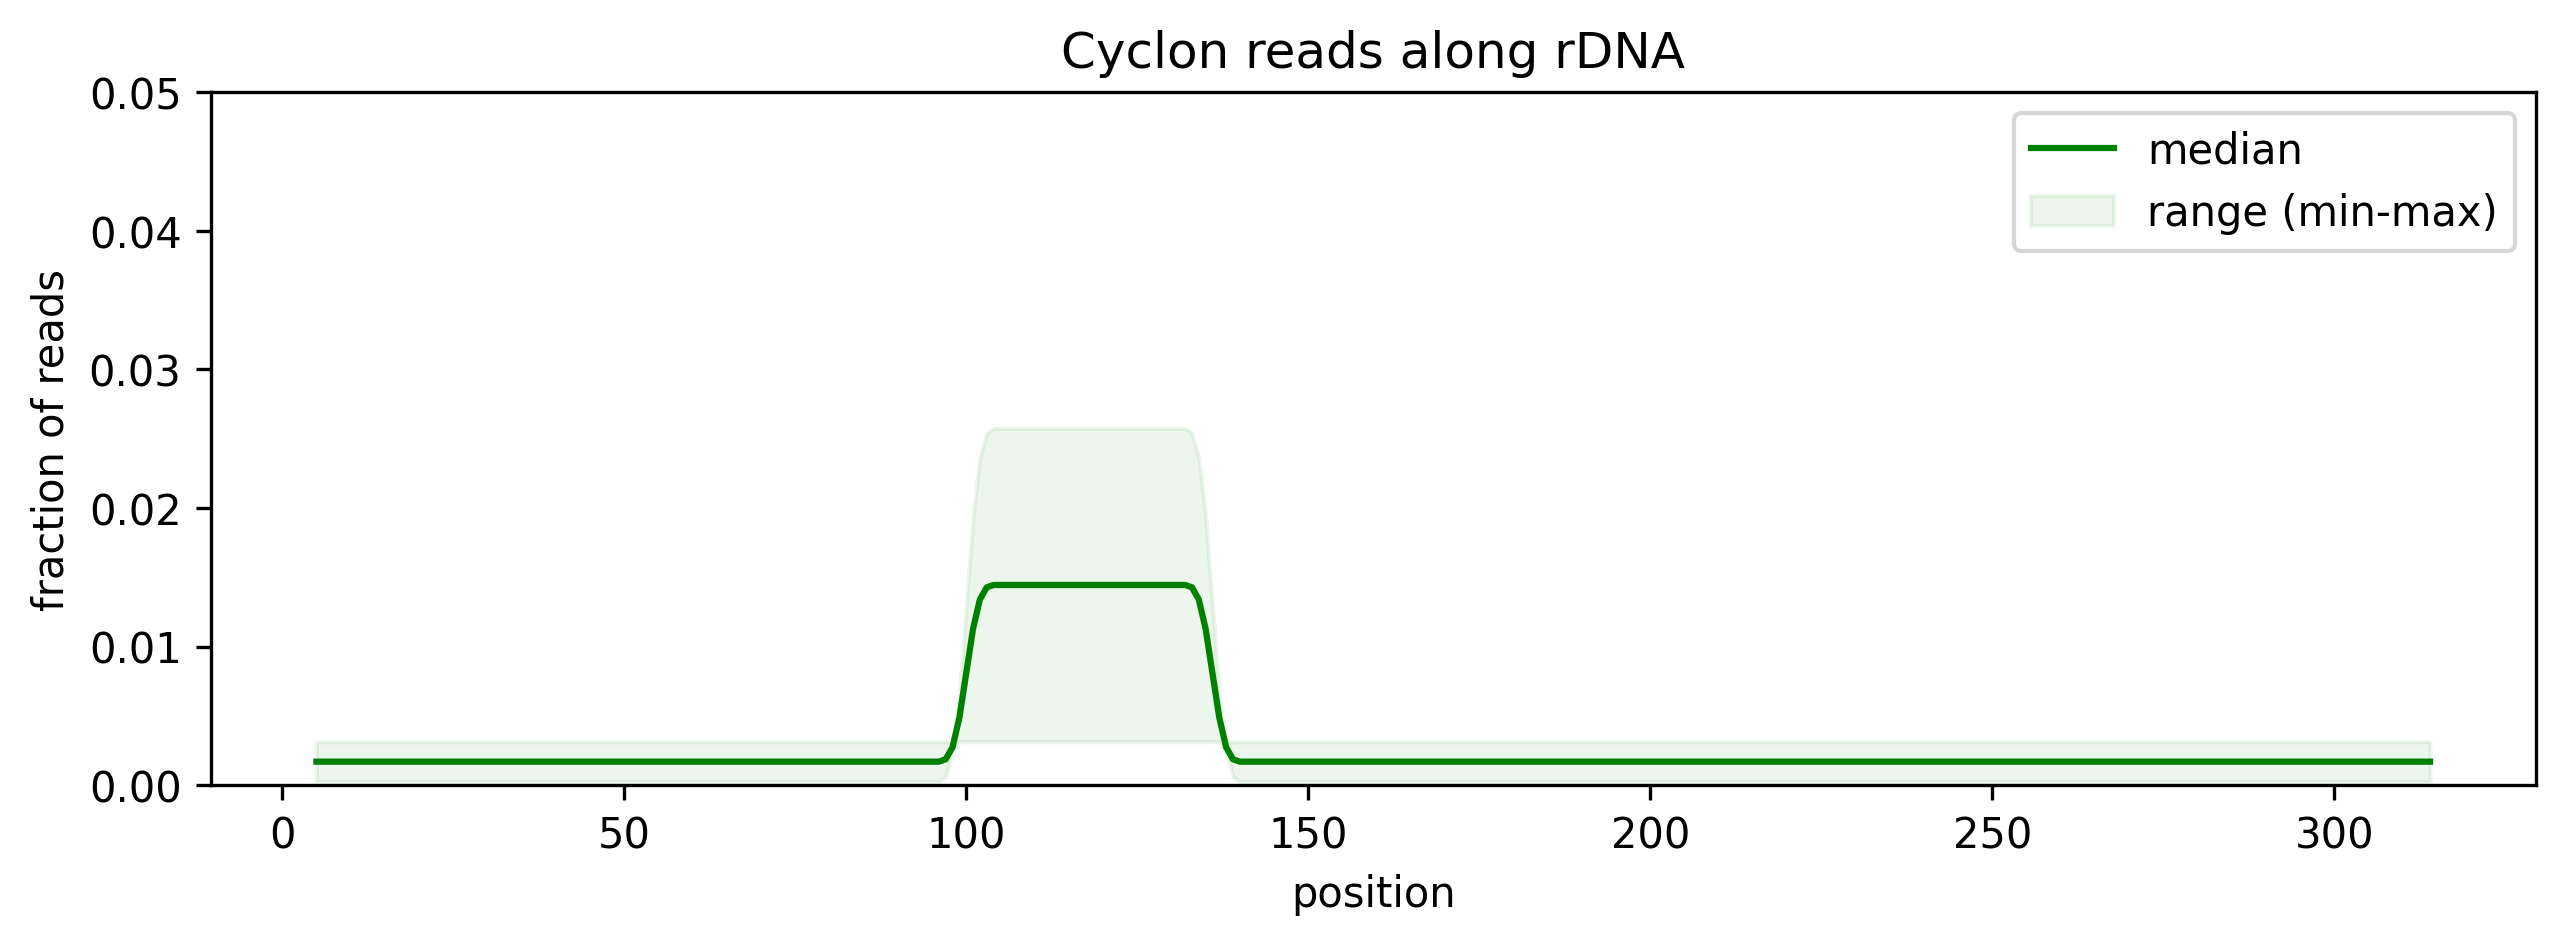

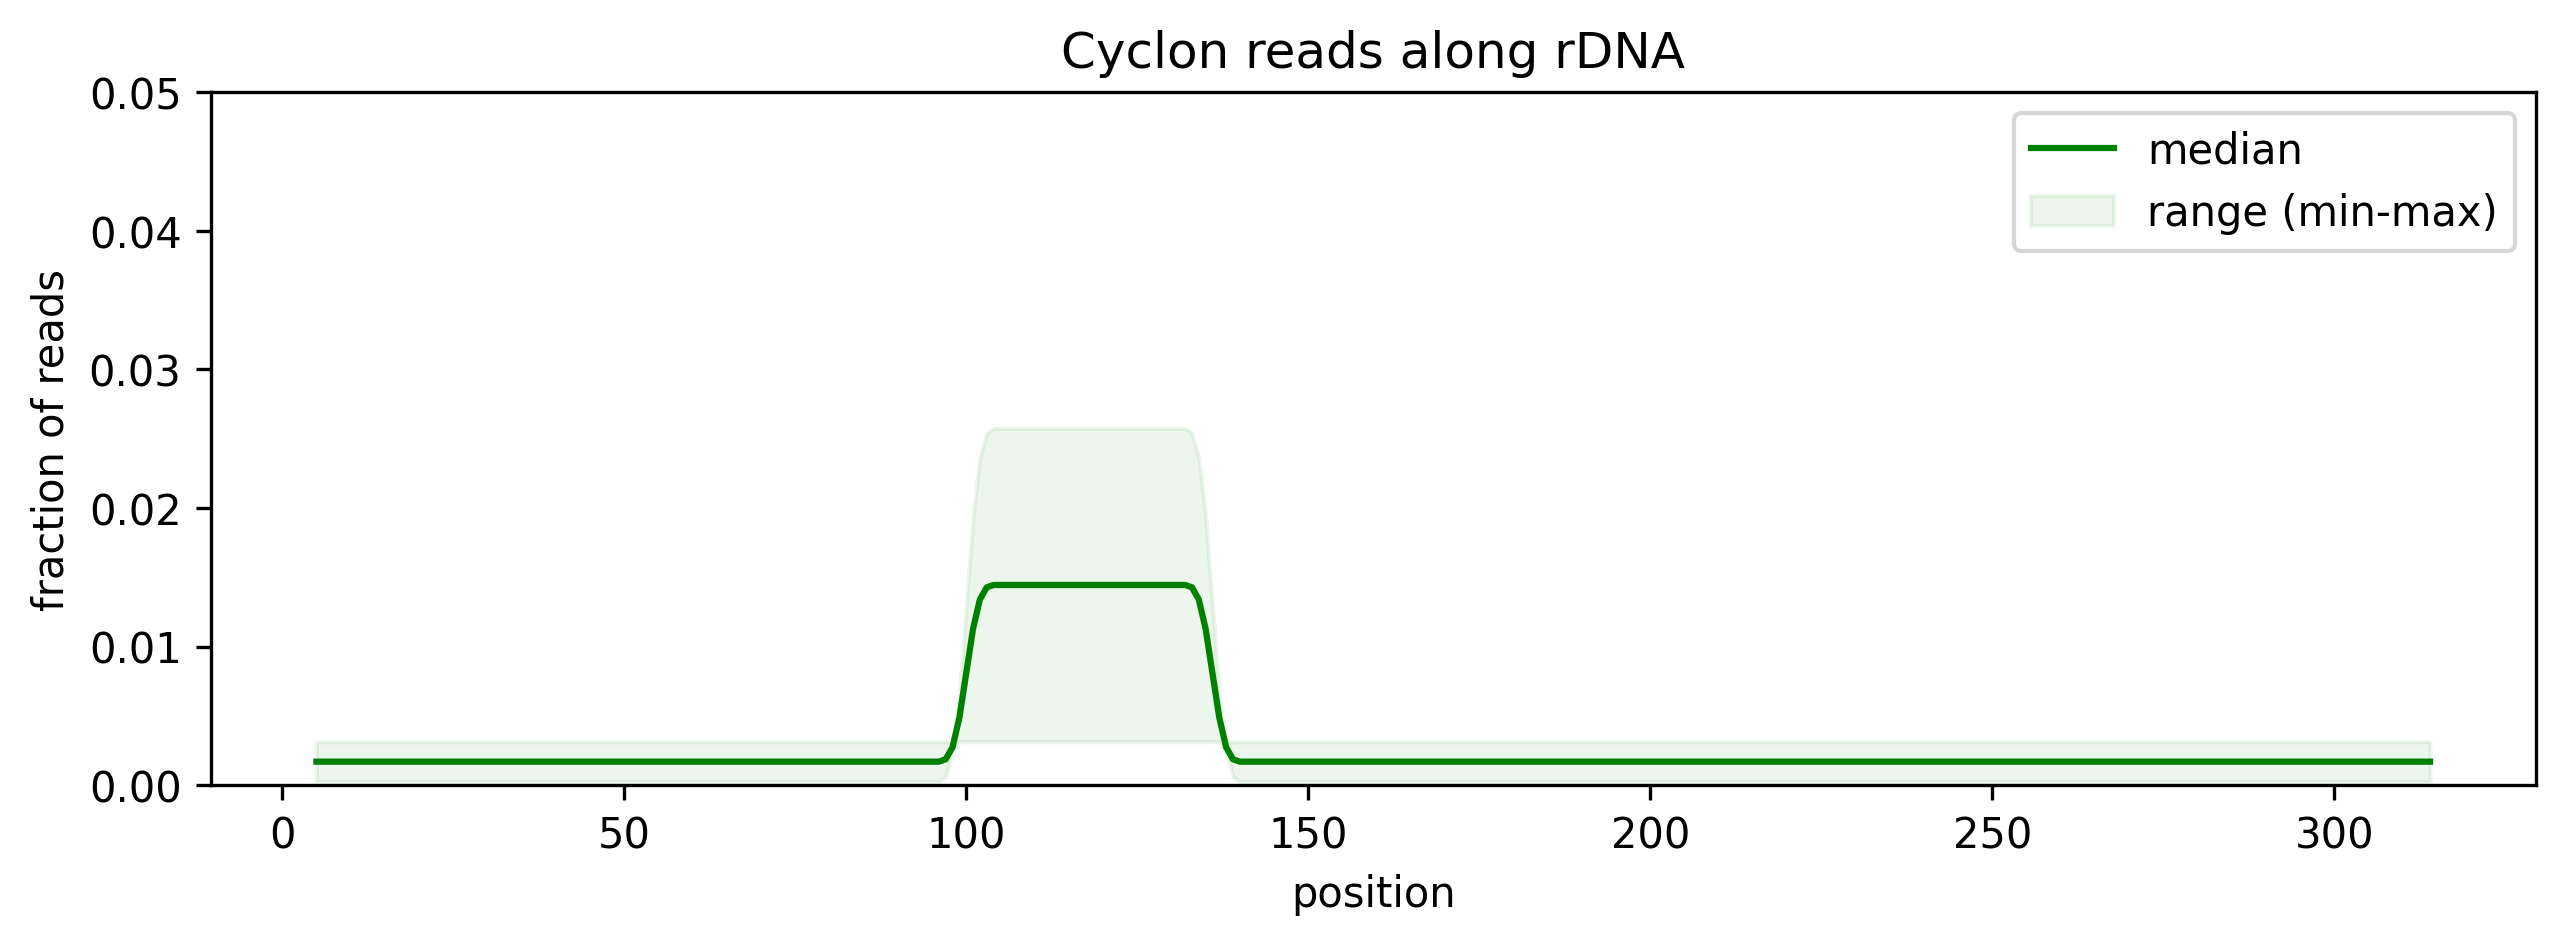

In [15]:
df03_RNA5S1_read_04 = geneFromBigWig(gene_name="RNA5S1", data_path=bwDir_04, data_files=data_files_read_04, gtf=gtf,ranges=flank)
df04_RNA5S1_read_14 = geneFromBigWig(gene_name="RNA5S1", data_path=bwDir_14, data_files=data_files_read_14, gtf=gtf,ranges=flank)

df12_RNA5S1 = tt.profiles.preprocess(df03_RNA5S1_read_04,
                                     let_in=['Cyclon'], 
                                     let_out=["CPM", "Cyclon-"],stats=True)
df22_RNA5S1 = tt.profiles.preprocess(df04_RNA5S1_read_14,
                                     let_in=['Cyclon'], 
                                     let_out=["CPM", "Cyclon-"],stats=True)

tt.plotting.plot_as_box_plot(df12_RNA5S1, figsize=(10,3), title="Cyclon reads along rDNA",
                            #  start=300,stop=7300,
                             dpi=300,ylim=(None,0.05),offset=0,fname='Fig_01_RNA5S1.png')
tt.plotting.plot_as_box_plot(df22_RNA5S1, figsize=(10,3), title="Cyclon reads along rDNA",
                            #  start=300,stop=7300,
                             dpi=300,ylim=(None,0.05),offset=0,fname='Fig_02_RNA5S1_14.png')